In [1]:
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
from matplotlib.pyplot import figure
import pandas as pd
from scipy import integrate
import numpy.matlib
from scipy.optimize import curve_fit
from scipy.stats import norm
import statistics
from collections import deque
from operator import add
from scipy.integrate import odeint

from statsmodels.tools.eval_measures import aic as sm_aic, aicc as sm_aicc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import lmfit
from lmfit import Model

import string
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
plt.style.use("seaborn-v0_8-white")
matplotlib.rcParams['axes.labelsize'] = 20
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['xtick.labelsize'] = 15
matplotlib.rcParams['xtick.major.size'] = 10
matplotlib.rcParams['xtick.minor.size'] = 5
matplotlib.rcParams['ytick.labelsize'] = 15
matplotlib.rcParams['ytick.major.size'] = 10
matplotlib.rcParams['ytick.minor.size'] = 5


# Functions 

In [2]:
def exp_decay(t, k):
    return np.log10(np.exp(-k * t))

def bi_decay(t, p, k1, k2):
    return np.log10(p * np.exp(-k1 * t) + (1 - p) * np.exp(-k2 * t))
m_exp = Model(exp_decay)
m_bi  = Model(bi_decay)

DeltaAICc = []
DeltaAIC = []
R2exp     = []
R2bi      = []


In [3]:

DECAY_PANELS = []

def add_decay_panel(title, x, y, t_fit, exp_fit, bi_fit, xlabel, yerr=None, data_label=None):
    """Store one decay panel for the combined multi-panel figure."""
    global DECAY_PANELS
    DECAY_PANELS = [p for p in DECAY_PANELS if p["title"] != title]
    DECAY_PANELS.append({
        "title": title,
        "x": np.asarray(x, dtype=float),
        "y": np.asarray(y, dtype=float),
        "yerr": None if yerr is None else np.asarray(yerr, dtype=float),
        "t_fit": np.asarray(t_fit, dtype=float),
        "exp_fit": np.asarray(exp_fit, dtype=float),
        "bi_fit": np.asarray(bi_fit, dtype=float),
        "xlabel": xlabel,
        "data_label": data_label if data_label is not None else ("Data ± SEM" if yerr is not None else "Data"),
    })



# Decay datasets (all manually extracted from decay_datasets.xlsx in github repo)
## Produces individual decay fits for Figure 1, and the corresponding best-fit parameter, AICs, and R^2 values for each fit that are shown in Figure 2 and Table S4

## Blazanin et. al 2022


[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 6
    # variables        = 1
    chi-square         = 32.1353654
    reduced chi-square = 6.42707309
    Akaike info crit   = 12.0691861
    Bayesian info crit = 11.8609456
    R-squared          = 0.96641273
[[Variables]]
    k:  0.04485508 +/- 0.00265719 (5.92%) (init = 0.03842855)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 35
    # data points      = 6
    # variables        = 3
    chi-square         = 0.99213131
    reduced chi-square = 0.33071044
    Akaike info crit   = -4.79795569
    Bayesian info crit = -5.42267728
    R-squared          = 0.99930234
[[Variables]]
    p:   0.99045428 +/- 0.00811007 (0.82%) (init = 0.85)
    k1:  0.05857202 +/- 0.00292010 (4.99%) (init = 0.05187597)
    k2:  0.02694122 +/- 0.00288426 (10.71%) (init = 0.02593798)
[[Correlations]] (unreported correla

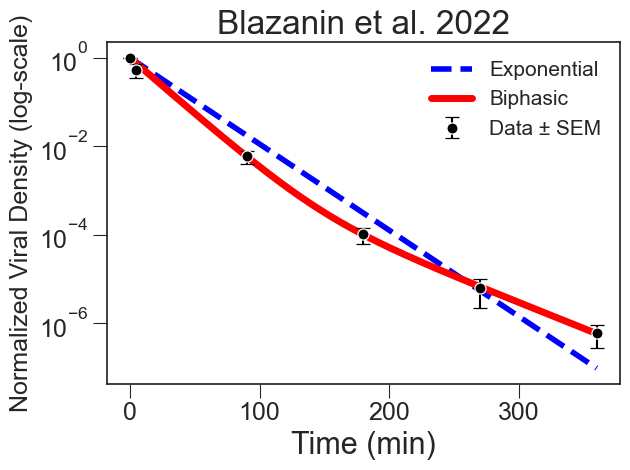

In [4]:
np.seterr(divide="ignore", invalid="ignore")
# Data
t = np.array([0, 5, 90, 180, 270, 360], dtype=float)
y_raw = np.array([100.0, 53.21583636, 0.60135105, 0.01025048, 0.00062364, 0.00006041], dtype=float)
sem_raw = np.array([0, 18.3472074, 0.193578602, 0.003958106, 0.000397707, 3.29611e-05], dtype=float)

# Conversions to logspace 
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0
lny10 = np.log10(y)
sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0 
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters 
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**6)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Blazanin et al. 2022", x=t_shift, y=y,yerr=sem,t_fit=t_fit, exp_fit=exp_fit,bi_fit=bi_fit, xlabel="Time (min)",)
plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8,color='black',markeredgecolor='white',markeredgewidth=0.9,zorder=5, label='Data ± SEM')
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.yscale('log')
plt.xlabel("Time (min)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Blazanin et al. 2022", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig('Blazanin.svg', bbox_inches="tight")

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calculations 
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calculations
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

#Store AIC(c) and R^2 values 
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Fischer et. al 2002


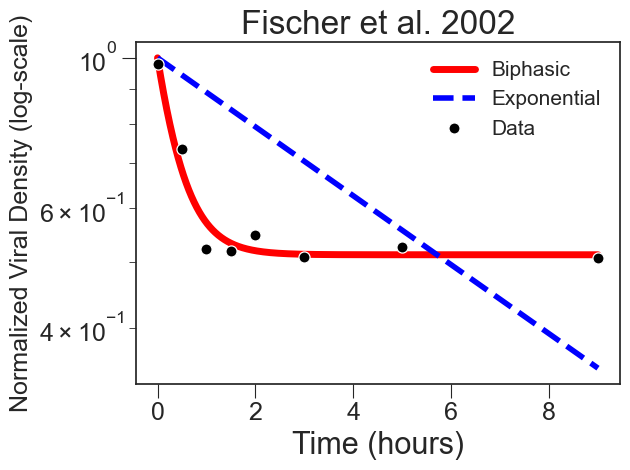

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 8
    # variables        = 1
    chi-square         = 0.18130135
    reduced chi-square = 0.02590019
    Akaike info crit   = -28.2962899
    Bayesian info crit = -28.2168483
    R-squared          = -1.41283693
[[Variables]]
    k:  0.11706300 +/- 0.03348106 (28.60%) (init = 0.02063249)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 62
    # data points      = 8
    # variables        = 3
    chi-square         = 0.00346675
    reduced chi-square = 6.9335e-04
    Akaike info crit   = -55.9518328
    Bayesian info crit = -55.7135081
    R-squared          = 0.95386298
##  Warning: uncertainties could not be estimated:
    k2:  at boundary
[[Variables]]
    p:   0.48752999 (init = 0.1)
    k1:  2.11593540 (init = 0.1781887)
    k2:  3.3751e-14 (init = 0.001807536)
AICc (exp): -27.62962319280186


In [5]:
# Data
t = np.array([0.0, 0.0, 0.0, 0.5, 0.5, 1.0, 1.5, 1.5, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 5.0, 5.0, 5.0, 9.0, 9.0, 9.0], dtype=float)

y_raw = np.array([37810132.21, 37085974.21, 36047601.47, 28487677.3, 27072397.03, 19760240.76, 20327854.49, 18917829.9, 16712695.6, 19992241.61, 25365801.77, 20079711.19, 19266206.59, 18323937.76, 22147071.52, 19744098.31, 17879457.16, 20211103.26, 19099526.36, 18188416.23], dtype=float)

# Normalize
y0 = y_raw[0]
y  = y_raw / y0

# Collapse replicates (mean per timepoint)
df = pd.DataFrame({"t": t, "y": y})
df_mean = df.groupby("t", as_index=False).mean()

t_use = df_mean["t"].values
y_use = df_mean["y"].values
lny10 = np.log10(y_use)

# Time shift so t = 0
t0 = t_use[0]
t_shift = t_use - t0

# Systematic initial guesses
mask = t_shift > 0

k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)

mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid

k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)

k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Fischer et al. 2002", x=t_shift, y=y_use, yerr=None, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)

plt.errorbar(t_shift, y_use, yerr=None,fmt='o', capsize=5, markersize=8,color='black', markeredgecolor='white',markeredgewidth=0.9, zorder=5, label='Data')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Fischer et al. 2002", fontsize=24)
plt.legend(fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Fischer2002.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)

print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared

print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Tsai et. al 2022

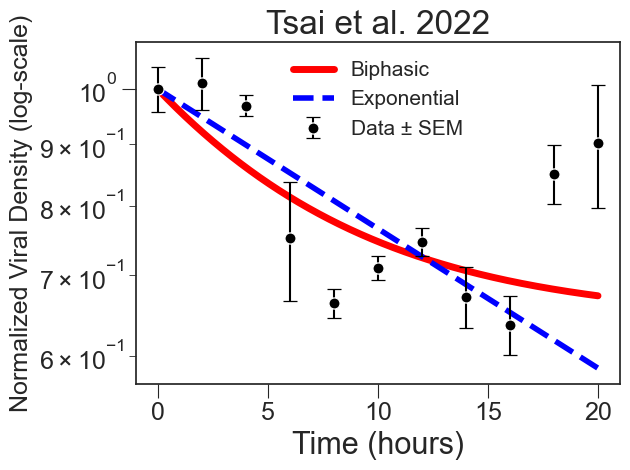

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 11
    # variables        = 1
    chi-square         = 124.238111
    reduced chi-square = 12.4238111
    Akaike info crit   = 28.6673517
    Bayesian info crit = 29.0652470
    R-squared          = -0.19994333
[[Variables]]
    k:  0.02671026 +/- 0.00395099 (14.79%) (init = 0.008105334)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 68
    # data points      = 11
    # variables        = 3
    chi-square         = 100.295008
    reduced chi-square = 12.5368760
    Akaike info crit   = 30.3124271
    Bayesian info crit = 31.5061130
    R-squared          = 0.32988664
[[Variables]]
    p:   0.35711418 +/- 1.47104667 (411.93%) (init = 0.3)
    k1:  0.12337169 +/- 0.46781340 (379.19%) (init = 0.05422539)
    k2:  2.2382e-13 +/- 0.01125048 (5026552106390.31%) (init = 1e-06)
[[Correlations]] (unrepo

In [6]:
# Data
t = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20], dtype=float)

y_raw = np.array([202617.6411, 204744.6866, 196278.9434, 152400.3531, 134426.5635, 143849.7318, 151264.6839, 136207.3063, 129103.0081, 172351.8028, 182705.2353], dtype=float)

sem_raw = np.array([8694.914103, 10294.01779, 3958.715285, 17320.22815, 3771.983432, 3266.109866, 3997.759218, 7980.240375, 7250.288586, 9647.246554, 21435.11917], dtype=float)

# Conversions to logspace 
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0

lny10 = np.log10(y)

sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0 
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0

k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)

mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid

k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)

k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters 
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    try:
        res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))
    except ValueError:
        pass

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit, color="blue", label="Exponential", linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18) 
plt.title("Tsai et al. 2022", fontsize=24)
plt.legend(fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Tsai.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)

print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared

print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Petterson et. al 2001

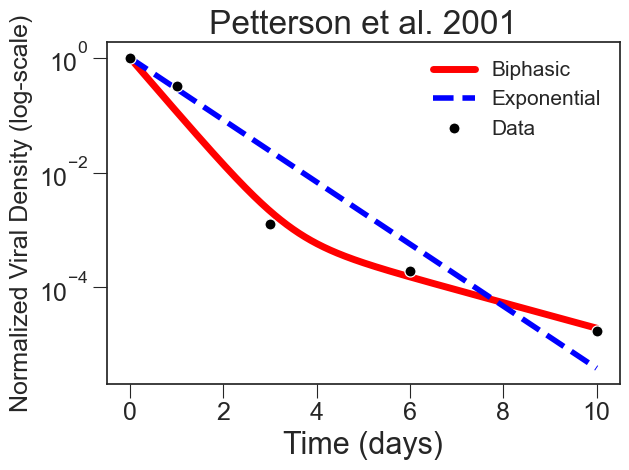

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 5
    # variables        = 1
    chi-square         = 2.24215566
    reduced chi-square = 0.56053892
    Akaike info crit   = -2.01000080
    Bayesian info crit = -2.40056288
    R-squared          = 0.86715937
[[Variables]]
    k:  1.24574380 +/- 0.14267312 (11.45%) (init = 0.9873322)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 98
    # data points      = 5
    # variables        = 3
    chi-square         = 0.25731107
    reduced chi-square = 0.12865553
    Akaike info crit   = -8.83453726
    Bayesian info crit = -10.0062235
    R-squared          = 0.98475513
[[Variables]]
    p:   0.99678794 +/- 0.00773886 (0.78%) (init = 0.9)
    k1:  2.17892759 +/- 0.42721202 (19.61%) (init = 2.751626)
    k2:  0.51102630 +/- 0.29105703 (56.96%) (init = 0.6046713)
[[Correlations]] (unreported correlat

In [7]:
# Data
t = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 6, 6, 6, 6, 10], dtype=float)

y_raw = np.array([22763.90033, 12840.62734, 7910.299753, 4121.560865, 10309.13243, 7143.772038, 4342.740169, 796.8000058, 27.56061827, 41.71685088, 30.14667576, 21.77787442, 11.57752836, 8.205704741, 5.219359346, 4.099079034, 2.435006955, 1.693262195, 1.115154311, 0.20796088], dtype=float)

# Collapse replicates FIRST (mean per timepoint), then normalize
df = pd.DataFrame({"t": t, "y_raw": y_raw})
df_mean = df.groupby("t", as_index=False).mean().sort_values("t", kind="mergesort")
t_use  = df_mean["t"].to_numpy(dtype=float)
y_mean = df_mean["y_raw"].to_numpy(dtype=float)
y0  = y_mean[0]
y   = y_mean / y0
lny10 = np.log10(y)

# Time shift so t = 0
t0 = t_use[0]
t_shift = t_use - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    try:
        res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift))
    except ValueError:
        pass

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Petterson et al. 2001", x=t_shift, y=y, yerr=None, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (days)",)
plt.errorbar(t_shift, y, yerr=None, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (days)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Petterson et al. 2001", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Petterson.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Parada et. al 2007

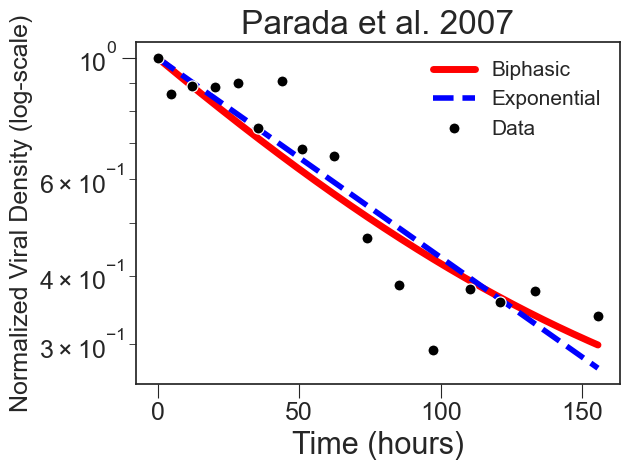

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 16
    # variables        = 1
    chi-square         = 0.08264329
    reduced chi-square = 0.00550955
    Akaike info crit   = -82.2529664
    Bayesian info crit = -81.4803777
    R-squared          = 0.84828899
[[Variables]]
    k:  0.00839705 +/- 5.3536e-04 (6.38%) (init = 0.008349736)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 72
    # data points      = 16
    # variables        = 3
    chi-square         = 0.07616023
    reduced chi-square = 0.00585848
    Akaike info crit   = -79.5600735
    Bayesian info crit = -77.2423073
    R-squared          = 0.86019015
##  Warning: uncertainties could not be estimated:
    k2:  at boundary
[[Variables]]
    p:   0.83073452 (init = 0.45)
    k1:  0.01195330 (init = 0.004798726)
    k2:  1.1102e-15 (init = 0.002211091)
AICc (exp): -81.96725209765

In [8]:
# Data
t = np.array([0.0, 4.8, 12.0, 20.2, 28.4, 35.3, 44.1, 50.9, 62.3, 74.0, 85.1, 97.1, 110.4, 120.9, 133.2, 155.5], dtype=float)

y_raw = np.array([2536202.18685248, 2176519.32406599, 2251502.02647422, 2238913.27560244, 2279797.28140352, 1884438.29113276, 2298732.80246864, 1729912.03233589, 1679367.83976055, 1187478.63906522, 974688.58929201, 741943.68047960, 959904.45408251, 907089.46131084, 951732.84304300, 854787.67200146], dtype=float)

# Normalize
y0  = y_raw[0]
y   = y_raw / y0
lny10 = np.log10(y)

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Parada et al. 2007", x=t_shift, y=y, yerr=None, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)
plt.errorbar(t_shift, y, yerr=None, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Parada et al. 2007", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Parada.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Mathias et. al 1995

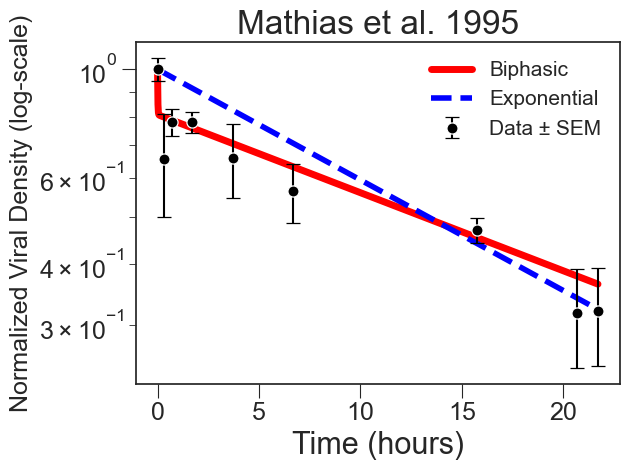

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 9
    # variables        = 1
    chi-square         = 29.1110211
    reduced chi-square = 3.63887764
    Akaike info crit   = 12.5650303
    Bayesian info crit = 12.7622549
    R-squared          = 0.72505575
[[Variables]]
    k:  0.05202616 +/- 0.00630819 (12.13%) (init = 0.03886842)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 60
    # data points      = 9
    # variables        = 3
    chi-square         = 3.06036079
    reduced chi-square = 0.51006013
    Akaike info crit   = -3.70822587
    Bayesian info crit = -3.11655214
    R-squared          = 0.91635259
[[Variables]]
    p:   0.19182230 +/- 0.02444207 (12.74%) (init = 0.05)
    k1:  71.7188376 +/- 7.5179e+08 (1048243029.34%) (init = 0.07912808)
    k2:  0.03673763 +/- 0.00320687 (8.73%) (init = 0.03956404)
[[Correlations]] (unreport

In [9]:
# Data
t = np.array([0.301492509, 0.599487704, 0.990221995, 1.97803205, 4.002976334, 6.991249481, 16.02746235, 20.98279322, 22.01305342], dtype=float)

y_raw = np.array([41282087.02, 27047379.34, 32230083.71, 32183761.98, 27210120.27, 23251457.29, 19395276.0, 13141432.94, 13211940.35], dtype=float)

sem_raw = np.array([2287801.399, 6477663.089, 2097595.369, 1643396.489, 4724816.148, 3181441.794, 1151894.272, 3021980.274, 2989596.058], dtype=float)

# Conversions to logspace
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0
lny10 = np.log10(y)
sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Mathias et al. 1995", x=t_shift, y=y, yerr=sem, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)
plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Mathias et al. 1995", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Mathias.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## DiPietro et. al 2023

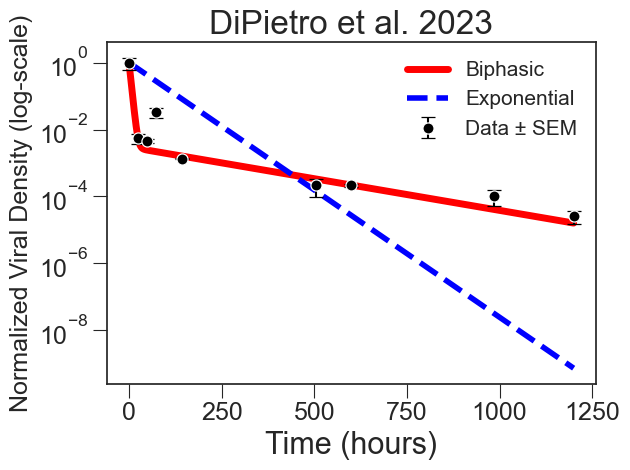

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 9
    # variables        = 1
    chi-square         = 8824.93447
    reduced chi-square = 1103.11681
    Akaike info crit   = 63.9930069
    Bayesian info crit = 64.1902315
    R-squared          = -1.84929351
[[Variables]]
    k:  0.01752285 +/- 0.00439772 (25.10%) (init = 0.004829834)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 71
    # data points      = 9
    # variables        = 3
    chi-square         = 110.577412
    reduced chi-square = 18.4295686
    Akaike info crit   = 28.5764213
    Bayesian info crit = 29.1680951
    R-squared          = 0.89352083
[[Variables]]
    p:   0.99700312 +/- 8.1207e-04 (0.08%) (init = 0.3)
    k1:  0.23988050 +/- 0.10662920 (44.45%) (init = 0.01212063)
    k2:  0.00435943 +/- 8.3614e-04 (19.18%) (init = 0.002854954)
[[Correlations]] (unreported corre

In [10]:
# Data
t = np.array([0, 24, 48, 72, 144, 504, 600, 984, 1200], dtype=float)

y_raw = np.array([2.11e+08, 1.17e+06, 9.72e+05, 7.03e+06, 2.83e+05, 4.54e+04, 4.57e+04, 2.15e+04, 5.62e+03], dtype=float)

sem_raw = np.array([8.12e+07, 3.74e+05, 1.32e+05, 2.26e+06, 1.48e+04, 2.47e+04, 4.55e+03, 1.04e+04, 2.39e+03], dtype=float)

# Conversions to logspace
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0
lny10 = np.log10(y)
sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("DiPietro et al. 2023", x=t_shift, y=y, yerr=sem, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)
plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("DiPietro et al. 2023", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("DiPietro.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Wei et. al 2018 

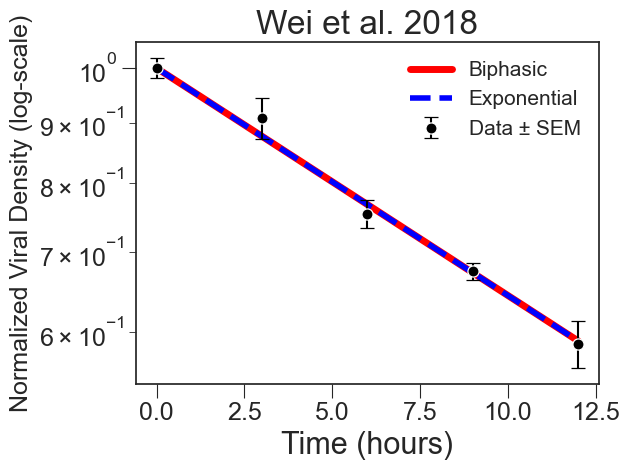

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 5
    # variables        = 1
    chi-square         = 1.23383558
    reduced chi-square = 0.30845889
    Akaike info crit   = -4.99655121
    Bayesian info crit = -5.38711329
    R-squared          = 0.99163354
[[Variables]]
    k:  0.04399404 +/- 8.4743e-04 (1.93%) (init = 0.04737084)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 86
    # data points      = 5
    # variables        = 3
    chi-square         = 1.23383558
    reduced chi-square = 0.61691779
    Akaike info crit   = -0.99655121
    Bayesian info crit = -2.16823747
    R-squared          = 0.99163354
##  Warning: uncertainties could not be estimated:
    p:   at boundary
[[Variables]]
    p:   1.00000000 (init = 0.8)
    k1:  0.04399404 (init = 0.09407538)
    k2:  0.67673251 (init = 0.04703769)
AICc (exp): -3.6632178720442425
A

In [11]:
# Data
t = np.array([0, 3, 6, 9, 12], dtype=float)

y_raw = np.array([802451.966, 728193.0919, 605626.391, 541879.6932, 470563.513], dtype=float)

sem_raw = np.array([16002.55233, 29183.09833, 16326.15273, 8830.089292, 21443.38687], dtype=float)

# Conversions to logspace
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0
lny10 = np.log10(y)
sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Wei et al. 2018", x=t_shift, y=y, yerr=sem, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)
plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Wei et al. 2018", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Wei.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Pleyer et. al 2024

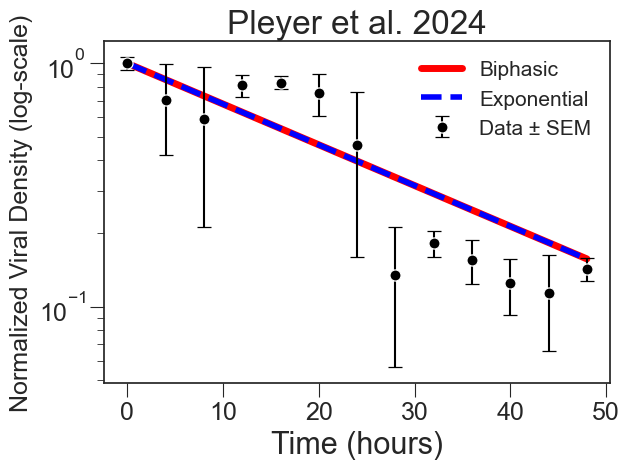

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 13
    # variables        = 1
    chi-square         = 90.6802117
    reduced chi-square = 7.55668431
    Akaike info crit   = 27.2510674
    Bayesian info crit = 27.8160168
    R-squared          = 0.73323247
[[Variables]]
    k:  0.03854187 +/- 0.00414103 (10.74%) (init = 0.05189655)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 42
    # data points      = 13
    # variables        = 3
    chi-square         = 90.6802117
    reduced chi-square = 9.06802117
    Akaike info crit   = 31.2510674
    Bayesian info crit = 32.9459155
    R-squared          = 0.73323201
[[Variables]]
    p:   0.74553086 +/- 1.7119e+09 (229621286413.93%) (init = 0.1)
    k1:  0.03854185 +/- 4565.79074 (11846320.97%) (init = 0.01887234)
    k2:  0.03854183 +/- 16141.9457 (41881628.31%) (init = 0.009436168)
[[Correlati

In [12]:
# Data
t = np.array([0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48], dtype=float)

y_raw = np.array([163711.5681, 115716.056, 96829.99531, 132957.6663, 136419.0502, 124134.2354, 75277.98245, 22015.87514, 29891.48637, 25514.10007, 20421.66254, 18711.90301, 23409.13658], dtype=float)

sem_raw = np.array([10074.35193, 47049.367, 61973.34048, 13415.16511, 8505.258222, 24238.06015, 49005.29171, 12773.79597, 3612.09726, 5288.364927, 5343.626499, 7930.872798, 2441.556702], dtype=float)

# Conversions to logspace
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0
lny10 = np.log10(y)
sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Pleyer et al. 2024", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Pleyer.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Fischer et. al 2004

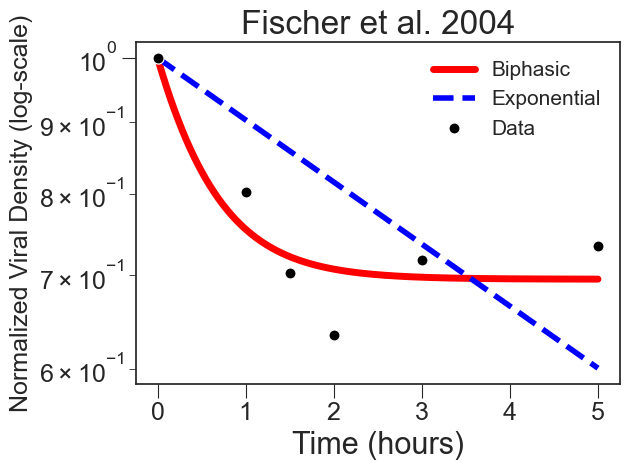

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 6
    # variables        = 1
    chi-square         = 0.02998702
    reduced chi-square = 0.00599740
    Akaike info crit   = -29.7925014
    Bayesian info crit = -30.0007420
    R-squared          = -0.30531437
[[Variables]]
    k:  0.10190423 +/- 0.02776421 (27.25%) (init = 0.002527103)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 93
    # data points      = 6
    # variables        = 3
    chi-square         = 0.00378560
    reduced chi-square = 0.00126187
    Akaike info crit   = -38.2098688
    Bayesian info crit = -38.8345904
    R-squared          = 0.83521560
[[Variables]]
    p:   0.30471217 +/- 0.15001198 (49.23%) (init = 0.15)
    k1:  1.63434303 +/- 2.19282576 (134.17%) (init = 0.2350506)
    k2:  1.3869e-12 +/- 0.00641852 (462799650354.71%) (init = 1e-06)
[[Correlations]] (unrepo

In [13]:
# Data
t = np.array([0.0, 1.0, 1.5, 2.0, 3.0, 5.0], dtype=float)

y_raw = np.array([5615965588, 4503350764, 3941541812, 3560037725, 4031061663, 4122920149], dtype=float)

# Normalize
y0  = y_raw[0]
y   = y_raw / y0
lny10 = np.log10(y)

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
plt.errorbar(t_shift, y, yerr=None, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Fischer et al. 2004", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Fischer2004.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Boixereu et. al 2002

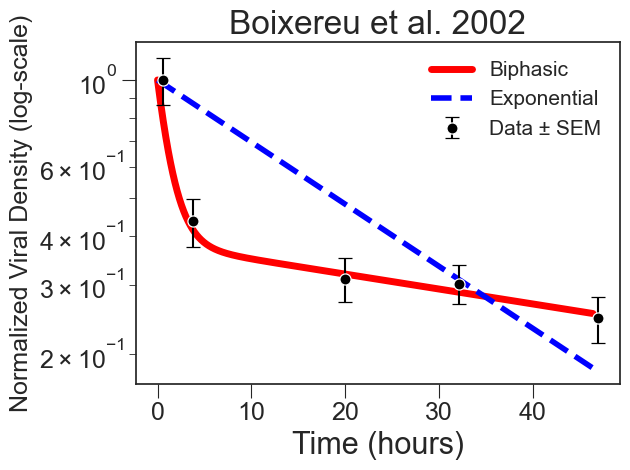

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 5
    # variables        = 1
    chi-square         = 43.3587459
    reduced chi-square = 10.8396865
    Akaike info crit   = 12.8003526
    Bayesian info crit = 12.4097905
    R-squared          = 0.34475722
[[Variables]]
    k:  0.03648718 +/- 0.00698939 (19.16%) (init = 0.0124954)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 27
    # data points      = 5
    # variables        = 3
    chi-square         = 0.27396545
    reduced chi-square = 0.13698273
    Akaike info crit   = -8.52095593
    Bayesian info crit = -9.69264219
    R-squared          = 0.99673915
[[Variables]]
    p:   0.61888954 +/- 0.03282851 (5.30%) (init = 0.2)
    k1:  0.68830444 +/- 0.15821426 (22.99%) (init = 0.02754717)
    k2:  0.00877356 +/- 0.00255130 (29.08%) (init = 0.01377358)
[[Correlations]] (unreported correla

In [14]:
# Data
t = np.array([0.533476765, 3.777837868, 20.00337639, 32.0744063, 46.92239905], dtype=float)

y_raw = np.array([22552688.34, 9850086.814, 7010766.392, 6822288.194, 5560482.389], dtype=float)

sem_raw = np.array([3131933.434, 1375842.133, 906093.6577, 771848.3237, 741739.2534], dtype=float)

# Conversions to logspace
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0

lny10 = np.log10(y)

sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0

k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)

mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid

k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)

k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Boixereu et al. 2002", x=t, y=y, yerr=sem, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)

plt.errorbar(t, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Boixereu et al. 2002", fontsize=24)
plt.legend(fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Boixereu.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)

print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared

print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Shaffer et. al 2024

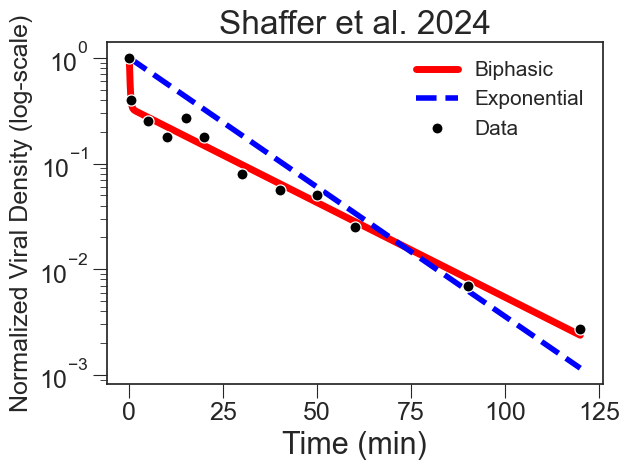

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 12
    # variables        = 1
    chi-square         = 1.10224708
    reduced chi-square = 0.10020428
    Akaike info crit   = -26.6506690
    Bayesian info crit = -26.1657624
    R-squared          = 0.81776328
[[Variables]]
    k:  0.05635379 +/- 0.00408416 (7.25%) (init = 0.04180972)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 12
    # variables        = 3
    chi-square         = 0.07337012
    reduced chi-square = 0.00815224
    Akaike info crit   = -55.1657422
    Bayesian info crit = -53.7110223
    R-squared          = 0.98786957
[[Variables]]
    p:   0.66353466 +/- 0.03532449 (5.32%) (init = 0.05)
    k1:  4.57357296 +/- 2.61349819 (57.14%) (init = 0.08010535)
    k2:  0.04129186 +/- 0.00186025 (4.51%) (init = 0.04005267)
[[Correlations]] (unreported cor

In [15]:
# Data
t = np.array([0.0, 0.5, 5.0, 10.0, 15.0, 20.0, 30.0, 40.0, 50.0, 60.0, 90.0, 120.0], dtype=float)

y_raw = np.array([1.00e9, 3.97e8, 2.53e8, 1.78e8, 2.68e8, 1.80e8, 8.00e7, 5.67e7, 5.06e7, 2.53e7, 7.00e6, 2.71e6], dtype=float)

# Normalize
y0  = y_raw[0]
y   = y_raw / y0

lny10 = np.log10(y)

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0

k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)

mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid

k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)

k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Shaffer et al. 2024", x=t_shift, y=y, yerr=None, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (min)",)

plt.errorbar(t_shift, y, yerr=None, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (min)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Shaffer et al. 2024", fontsize=24)
plt.legend(fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Shaffer.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)

print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared

print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Suttle et. al 1992

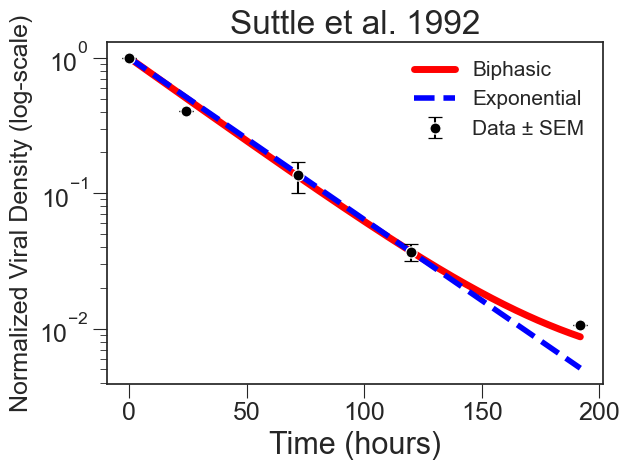

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 5
    # variables        = 1
    chi-square         = 0.11985629
    reduced chi-square = 0.02996407
    Akaike info crit   = -16.6544988
    Bayesian info crit = -17.0450608
    R-squared          = 0.95394295
[[Variables]]
    k:  0.02748648 +/- 1.9400e-04 (0.71%) (init = 0.02190265)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 103
    # data points      = 5
    # variables        = 3
    chi-square         = 0.02739918
    reduced chi-square = 0.01369959
    Akaike info crit   = -20.0334003
    Bayesian info crit = -21.2050865
    R-squared          = 0.99298760
##  Warning: uncertainties could not be estimated:
    k2:  at boundary
[[Variables]]
    p:   0.99548680 (init = 0.65)
    k1:  0.02849394 (init = 0.03432366)
    k2:  1.5721e-12 (init = 0.01716183)
AICc (exp): -15.321165418886123

In [16]:
np.seterr(divide="ignore", invalid="ignore")
# Data
t = np.array([0, 24, 72, 120, 192], dtype=float)

y_raw = np.array([2756.239157, 1121.373637, 373.9955354, 101.7198893, 29.56440239], dtype=float)

sem_raw = np.array([0, 0, 96.75732544, 14.46994458, 0], dtype=float)

# Conversions to logspace
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0

lny10 = np.log10(y)

sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0

k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)

mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid

k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)

k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min  = 0
    params_bi["p"].max  = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Suttle et al. 1992", x=t_shift, y=y, yerr=sem, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)

plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Suttle et al. 1992", fontsize=24)
plt.legend(fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Suttle.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)

print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared

print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Chen et. al 2011

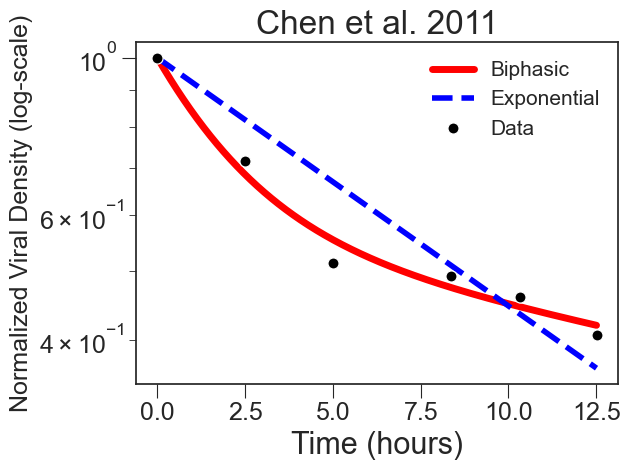

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 6
    # variables        = 1
    chi-square         = 0.01932313
    reduced chi-square = 0.00386463
    Akaike info crit   = -32.4292713
    Bayesian info crit = -32.6375118
    R-squared          = 0.81705503
[[Variables]]
    k:  0.08063758 +/- 0.00749741 (9.30%) (init = 0.04886009)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 96
    # data points      = 6
    # variables        = 3
    chi-square         = 0.00205210
    reduced chi-square = 6.8403e-04
    Akaike info crit   = -41.8839047
    Bayesian info crit = -42.5086263
    R-squared          = 0.98057139
[[Variables]]
    p:   0.43568018 +/- 0.20504696 (47.06%) (init = 0.55)
    k1:  0.41887890 +/- 0.27854646 (66.50%) (init = 0.1130016)
    k2:  0.02419875 +/- 0.03030549 (125.24%) (init = 0.05650081)
[[Correlations]] (unreported cor

In [17]:
# Data
t = np.array([0.022909754, 2.529402414, 5.029224561, 8.393255427, 10.35038706, 12.53091768], dtype=float)

y_raw = np.array([15072623.46, 10773912.13, 7746758.059, 7418296.702, 6929632.618, 6126386.167], dtype=float)

# Normalize
y0  = y_raw[0]
y   = y_raw / y0
lny10 = np.log10(y)

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0
k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)
mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid
k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)
k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Chen et al. 2011", x=t_shift, y=y, yerr=None, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)
plt.errorbar(t_shift, y, yerr=None, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Chen et al. 2011", fontsize=24)
plt.legend(fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Chen.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calc
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)
print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calc
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared
print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## French et. al 2023

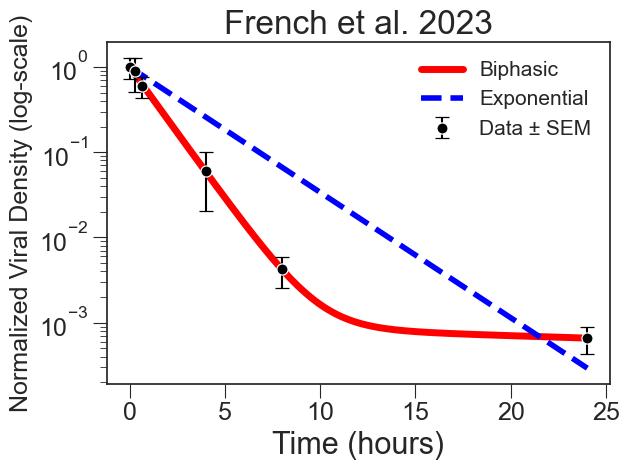

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 6
    # variables        = 1
    chi-square         = 59.2963389
    reduced chi-square = 11.8592678
    Akaike info crit   = 15.7447286
    Bayesian info crit = 15.5364880
    R-squared          = 0.78151610
[[Variables]]
    k:  0.33871722 +/- 0.04851893 (14.32%) (init = 0.2895379)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 90
    # data points      = 6
    # variables        = 3
    chi-square         = 0.09816487
    reduced chi-square = 0.03272162
    Akaike info crit   = -18.6771982
    Bayesian info crit = -19.3019198
    R-squared          = 0.99970982
[[Variables]]
    p:   0.99902623 +/- 0.00162973 (0.16%) (init = 0.65)
    k1:  0.71204000 +/- 0.03253690 (4.57%) (init = 0.7007046)
    k2:  0.01624717 +/- 0.06978954 (429.55%) (init = 0.1162398)
[[Correlations]] (unreported correlat

In [18]:
# Data
t = np.array([0.00, 0.29, 0.63, 4.03, 7.98, 24.02], dtype=float)

y_raw = np.array([149473.6468, 132512.0390, 89460.84589, 9022.910868, 635.7815825, 98.53075994], dtype=float)

sem_raw = np.array([41643.25622, 56905.40981, 25326.92065, 5984.35683, 252.4775902, 34.92712345], dtype=float)

# Conversions to logspace 
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0

lny10 = np.log10(y)

sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0 
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0

k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)

mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid

k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)

k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters 
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min = 0
    params_bi["p"].max = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("French et al. 2023", x=t_shift, y=y, yerr=sem, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)

plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18) 
plt.title("French et al. 2023", fontsize=24)
plt.legend(fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("French.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calculations 
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)

print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calculations
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared

print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

#Store AIC(c) and R^2 values 
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)
R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Panagiotis et. al 2024

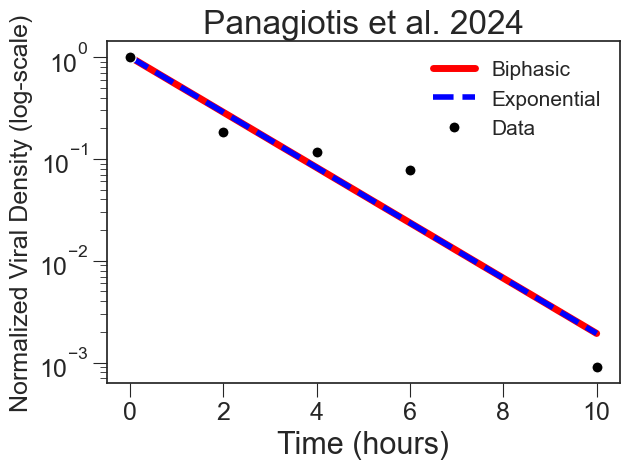

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 5
    # variables        = 1
    chi-square         = 0.43339455
    reduced chi-square = 0.10834864
    Akaike info crit   = -10.2277234
    Bayesian info crit = -10.6182855
    R-squared          = 0.91555908
[[Variables]]
    k:  0.62488910 +/- 0.06068273 (9.71%) (init = 0.6768804)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 51
    # data points      = 5
    # variables        = 3
    chi-square         = 0.43339455
    reduced chi-square = 0.21669728
    Akaike info crit   = -6.22772336
    Bayesian info crit = -7.39940963
    R-squared          = 0.91555908
##  Warning: uncertainties could not be estimated:
    p:   at boundary
[[Variables]]
    p:   1.7690e-12 (init = 0.85)
    k1:  22.0355262 (init = 2.223185)
    k2:  0.62488916 (init = 1.111593)
AICc (exp): -8.89439002949935
AICc (b

In [19]:
# Data
t = np.array([2, 4, 6, 8, 12], dtype=float)

y_raw = np.array([10827942.74, 2000065.794, 1258136.938, 833339.555, 9767.602919], dtype=float)

# Conversions to logspace
y0  = y_raw[0]
y   = y_raw / y0
lny10 = np.log10(y)

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0

k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)

mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid

k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)

k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min  = 0
    params_bi["p"].max  = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)

exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)

exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Panagiotis et al. 2024", x=t_shift, y=y, yerr=None, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (hours)",)

plt.errorbar(t_shift, y, yerr=None, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)

plt.yscale('log')
plt.xlabel("Time (hours)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Panagiotis et al. 2024", fontsize=24)
plt.legend(fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Panagiotis.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calculations 
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)

print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calculations
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared

print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

#Store AIC(c) and R^2 values 
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)

R2exp.append(R2_exp)
R2bi.append(R2_bi)

## Moebus et. al 1992

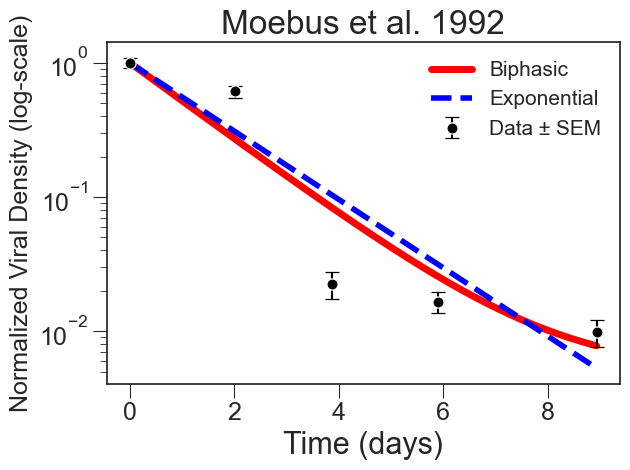

[[Model]]
    Model(exp_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 5
    # variables        = 1
    chi-square         = 107.029753
    reduced chi-square = 26.7574383
    Akaike info crit   = 17.3183447
    Bayesian info crit = 16.9277827
    R-squared          = 0.80986644
[[Variables]]
    k:  0.58616475 +/- 0.09023777 (15.39%) (init = 0.5225891)
[[Model]]
    Model(bi_decay)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 68
    # data points      = 5
    # variables        = 3
    chi-square         = 98.6784341
    reduced chi-square = 49.3392171
    Akaike info crit   = 20.9121426
    Bayesian info crit = 19.7404563
    R-squared          = 0.86110531
[[Variables]]
    p:   0.99501130 +/- 0.23222629 (23.34%) (init = 0.9)
    k1:  0.65712869 +/- 0.53098267 (80.80%) (init = 1.786611)
    k2:  8.3275e-11 +/- 0.70756389 (849672019994.04%) (init = 0.1714703)
[[Correlations]] (unreported c

In [20]:
# Data
t = np.array([0.11457165, 2.133666925, 3.982055043, 6.009605153, 9.051534236], dtype=float)

y_raw = np.array([99655.46484, 60977.13244, 2243.751548, 1652.518455, 980.8850175], dtype=float)

sem_raw = np.array([8911.333075, 6556.799302, 508.3542069, 299.6913146, 220.1592467], dtype=float)

# Conversions to logspace
y0  = y_raw[0]
y   = y_raw / y0
sem = sem_raw / y0

lny10 = np.log10(y)
sem_log10 = sem / (y * np.log(10))

# Time shift so t = 0
t0 = t[0]
t_shift = t - t0

# Systematic initial guesses
mask = t_shift > 0

k0 = -np.polyfit(t_shift[mask], lny10[mask], 1)[0] * np.log(10)
k0 = max(k0, 1e-6)

mid = np.median(t_shift[mask])
early = (t_shift > 0) & (t_shift <= mid)
late  = t_shift > mid

k1_0 = -np.polyfit(t_shift[early], lny10[early], 1)[0] * np.log(10)
k2_0 = -np.polyfit(t_shift[late],  lny10[late],  1)[0] * np.log(10)

k2_0 = max(k2_0, 1e-6)
k1_0 = max(k1_0, 2 * k2_0)
p_0_values = np.linspace(0.05, 0.95, 19)

# Setting initial parameters
params_exp = m_exp.make_params(k=k0)

# Error weights: use 1/sem_log10 where sem_log10>0, else neutral weight=1
w = np.where(sem_log10 > 0, 1/sem_log10, 1.0)

# Fit results
res_exp = m_exp.fit(lny10, params=params_exp, t=t_shift, weights=w)

res_bi_all = []
for p_0 in p_0_values:
    params_bi = m_bi.make_params(p=p_0, k1=k1_0, k2=k2_0)
    params_bi["p"].min  = 0
    params_bi["p"].max  = 1
    params_bi["k1"].min = 0
    params_bi["k2"].min = 0
    res_bi_all.append(m_bi.fit(lny10, params=params_bi, t=t_shift, weights=w))

res_bi = min(res_bi_all, key=lambda result: result.chisqr)

t_fit = np.linspace(t_shift.min(), t_shift.max(), 10**3)
exp_fit = m_exp.eval(params=res_exp.params, t=t_fit)
bi_fit  = m_bi.eval(params=res_bi.params,  t=t_fit)
exp_fit = 10**exp_fit
bi_fit  = 10**bi_fit

# Plotting
add_decay_panel("Moebus et al. 1992", x=t_shift, y=y, yerr=sem, t_fit=t_fit, exp_fit=exp_fit, bi_fit=bi_fit, xlabel="Time (days)",)

plt.errorbar(t_shift, y, yerr=sem, fmt='o', capsize=5, markersize=8, color='black', markeredgecolor='white', markeredgewidth=0.9, zorder=5, label='Data ± SEM')
plt.plot(t_fit, bi_fit,  color="red", label="Biphasic", linewidth = 5)
plt.plot(t_fit, exp_fit,color="blue", label="Exponential",linestyle = '--', linewidth = 4)
plt.yscale('log')
plt.xlabel("Time (days)", fontsize=22)
plt.ylabel("Normalized Viral Density (log-scale)", fontsize=18)
plt.title("Moebus et al. 1992", fontsize=24)
plt.legend(fontsize = 15)

plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)
plt.tight_layout()
plt.savefig("Moebus.svg", bbox_inches="tight")
plt.show()

# Fit parameters
print(res_exp.fit_report())
print(res_bi.fit_report())

#AICc calculations
AIC_exp = res_exp.aic
AIC_bi  = res_bi.aic
n_exp, k_exp = res_exp.ndata, res_exp.nvarys
n_bi,  k_bi  = res_bi.ndata,  res_bi.nvarys
AICc_exp = AIC_exp + (2*k_exp*(k_exp+1)) / (n_exp - k_exp - 1)
AICc_bi  = AIC_bi  + (2*k_bi*(k_bi+1))   / (n_bi - k_bi  - 1)

print("AICc (exp):", AICc_exp)
print("AICc (bi) :", AICc_bi)
print("Delta AICc (exp - bi):", AICc_exp - AICc_bi)

#R^2 calculations
R2_exp = res_exp.rsquared
R2_bi = res_bi.rsquared

print("R^2 (exp):", R2_exp)
print("R^2 (bi) :", R2_bi)

#Store AIC(c) and R^2 values
DeltaAICc.append(AICc_exp - AICc_bi)
DeltaAIC.append(AIC_exp - AIC_bi)

R2exp.append(R2_exp)
R2bi.append(R2_bi)

# Figure 1 : Combination of all decay panels

['DiPietro et al. 2023', 'Shaffer et al. 2024', 'French et al. 2023', 'Fischer et al. 2002', 'Mathias et al. 1995', 'Blazanin et al. 2022', 'Boixereu et al. 2002', 'Chen et al. 2011', 'Parada et al. 2007', 'Petterson et al. 2001', 'Suttle et al. 1992', 'Moebus et al. 1992', 'Wei et al. 2018', 'Panagiotis et al. 2024']


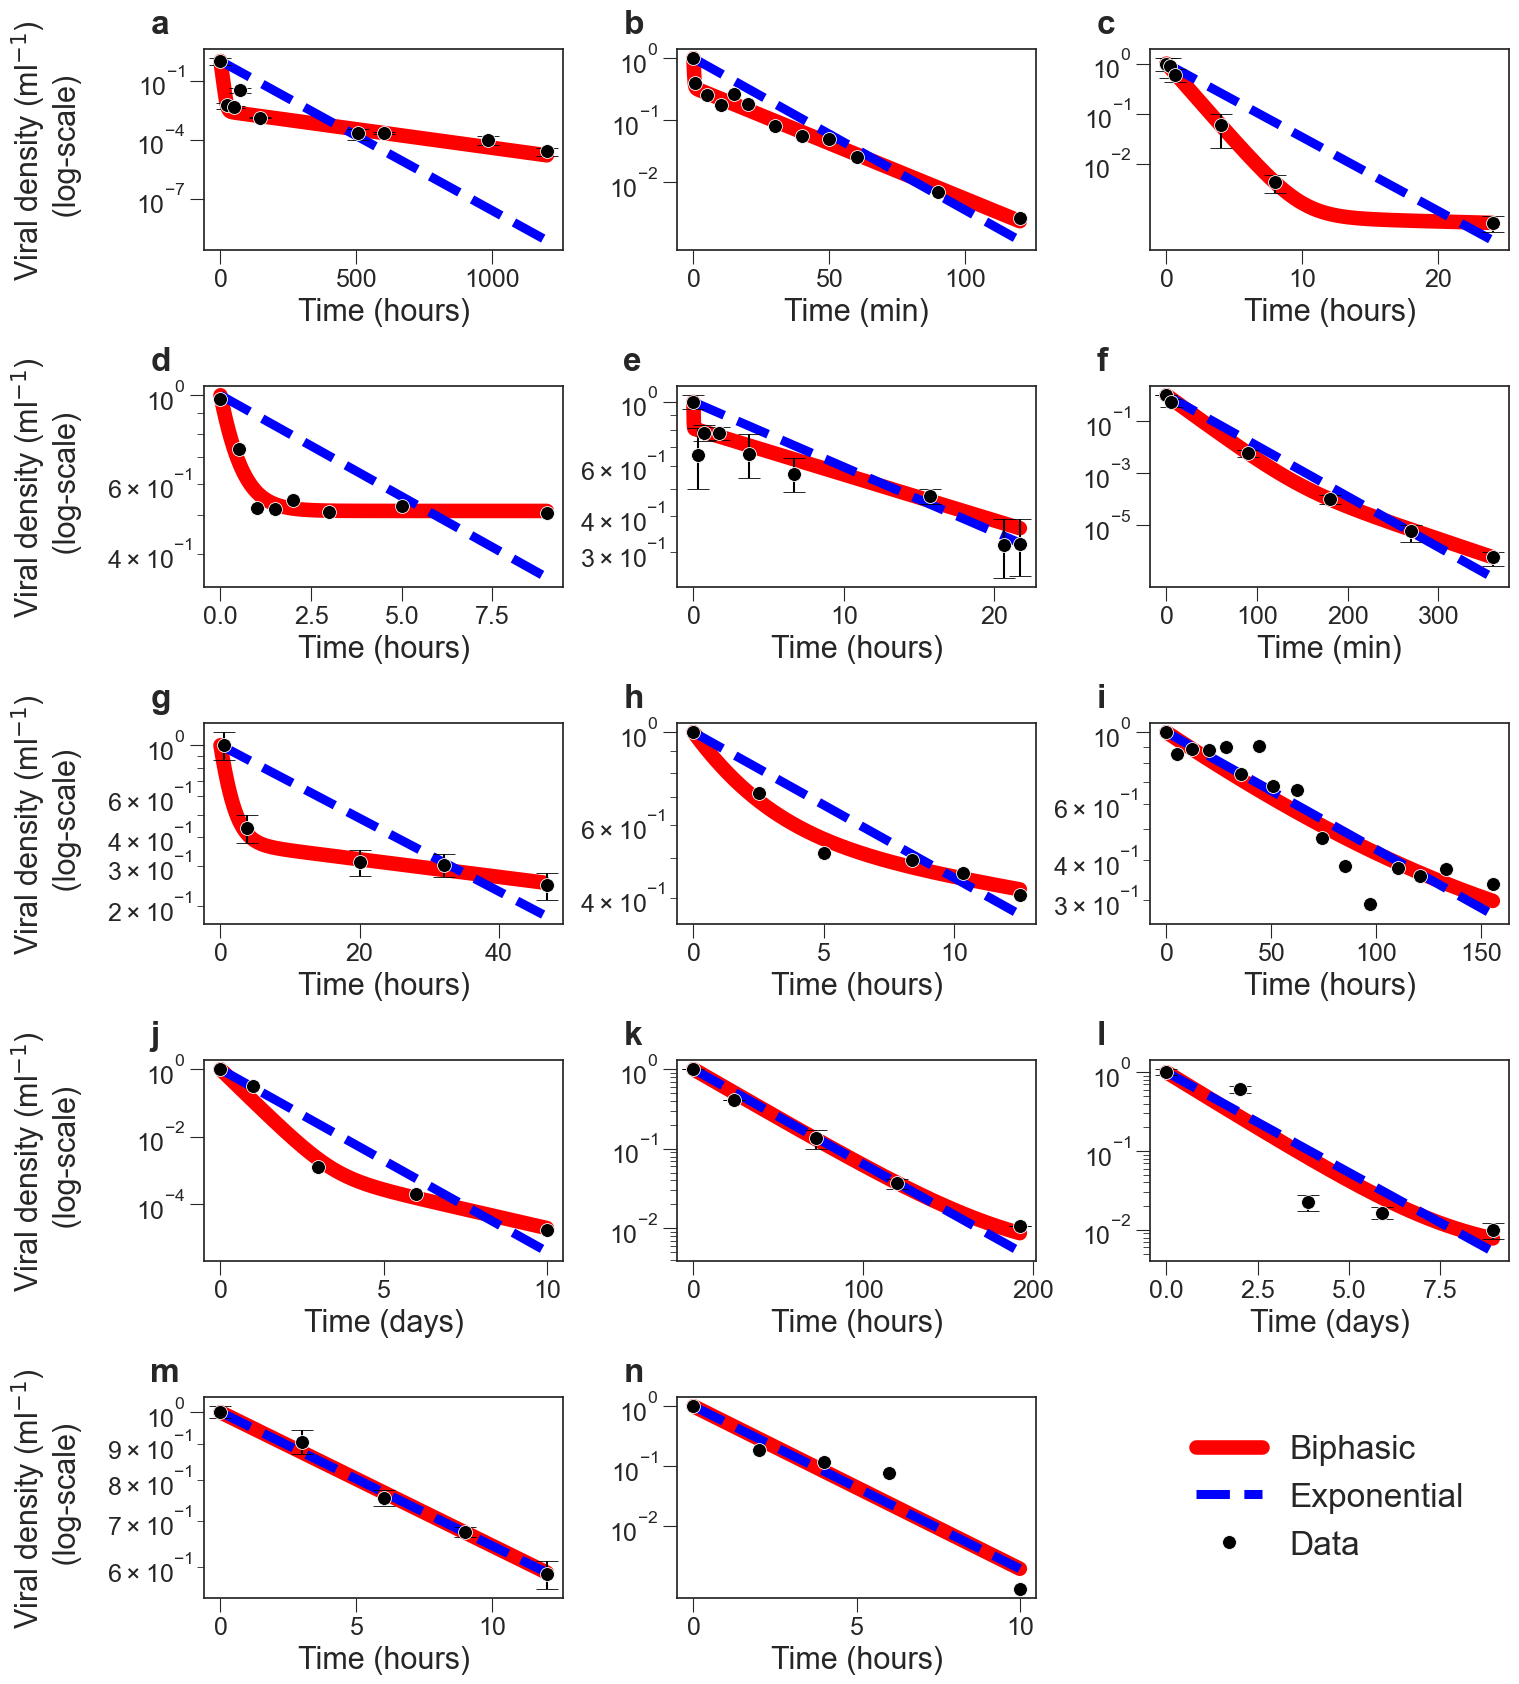

1. DiPietro et al. 2023: ΔAICc = 31.19
2. Shaffer et al. 2024: ΔAICc = 25.92
3. French et al. 2023: ΔAICc = 23.42
4. Fischer et al. 2002: ΔAICc = 22.32
5. Mathias et al. 1995: ΔAICc = 12.04
6. Blazanin et al. 2022: ΔAICc = 5.87
7. Boixereu et al. 2002: ΔAICc = -1.35
8. Chen et al. 2011: ΔAICc = -1.55
9. Parada et al. 2007: ΔAICc = -4.41
10. Petterson et al. 2001: ΔAICc = -15.84
11. Suttle et al. 1992: ΔAICc = -19.29
12. Moebus et al. 1992: ΔAICc = -26.26
13. Wei et al. 2018: ΔAICc = -26.67
14. Panagiotis et al. 2024: ΔAICc = -26.67


In [26]:
from matplotlib.ticker import FixedLocator, LogFormatterMathtext

# Study order corresponding to stored DeltaAICc values
study_order = ["Blazanin et al. 2022", "Fischer et al. 2002", "Tsai et al. 2022", "Petterson et al. 2001", "Parada et al. 2007", "Mathias et al. 1995", "DiPietro et al. 2023", "Wei et al. 2018", "Pleyer et al. 2024", "Fischer et al. 2004", "Boixereu et al. 2002", "Shaffer et al. 2024", "Suttle et al. 1992", "Chen et al. 2011", "French et al. 2023", "Panagiotis et al. 2024", "Moebus et al. 1992"]

# Delta AICc for each study
delta_aicc_map = dict(zip(study_order, DeltaAICc))

# Panel order from highest to lowest Delta AICc
def clean_study_name(name):
    name = name.split(" (")[0]
    name = name.replace("et. al", "et al.")
    name = name.replace("Blazinin", "Blazanin")
    return name

panel_order = (
    df.sort_values("DeltaAICc", ascending=False)["Paper"]
    .map(clean_study_name)
    .tolist()
)

print(panel_order)

# Order panels from highest to lowest Delta AICc
panel_order = sorted(panel_order, key=lambda title: delta_aicc_map[title], reverse=True)

# Validate panels 
panels = {p["title"]: p for p in DECAY_PANELS} 
missing = [title for title in panel_order if title not in panels] 
if missing: 
    raise ValueError("Run the study fit cells before this combined-figure cell. Missing: " + ", ".join(missing)) 
 
# Plot setup 
fig, axes = plt.subplots(5, 3, figsize=(15, 17)) 
axes = axes.ravel() 
 
legend_handles = None 
legend_labels = None 
panel_labels = list(string.ascii_lowercase) 
 
# Plot each panel 
for i, (ax, title) in enumerate(zip(axes, panel_order)): 
    p = panels[title] 
 
    data_handle = ax.errorbar(p["x"], p["y"], yerr=p["yerr"], fmt="o", capsize=8, markersize=10, color="black", markeredgecolor="white", markeredgewidth=0.6, zorder=5, label=p["data_label"],) 
    bi_handle, = ax.plot(p["t_fit"], p["bi_fit"], color="red", label="Biphasic", linewidth=10.5) 
    exp_handle, = ax.plot(p["t_fit"], p["exp_fit"], color="blue", linestyle="--", label="Exponential", linewidth=6.5) 
 
    ax.set_yscale("log") 
 
    # Panel label in top-left corner 
    ax.text(-0.15, 1.2, f"{panel_labels[i]}", transform=ax.transAxes, fontsize=24, fontweight="bold", va="top", ha="left") 
 
    ax.set_xlabel(p["xlabel"], fontsize=22) 
 
    # Y-axis label only on the left panel of each row, aligned across rows 
    if i % 3 == 0: 
        ax.set_ylabel("Viral density (ml$^{-1}$) \n (log-scale)", fontsize=22) 
        ax.yaxis.set_label_coords(-0.34, 0.5) 
    else: 
        ax.set_ylabel("") 
 
    ax.tick_params(axis="both", which="major", labelsize=18) 
    ax.tick_params(axis="both", which="minor", labelsize=18) 
 
    # Save legend handles once, but do not draw panel-level legends 
    if legend_handles is None: 
        data_legend_handle = Line2D([0], [0], marker="o", linestyle="None", markersize=10, color="black", markeredgecolor="white", markeredgewidth=0.6, label="Data") 
        legend_handles = [bi_handle, exp_handle, data_legend_handle] 
        legend_labels = ["Biphasic", "Exponential", "Data"] 

# Draw once so Matplotlib determines which log ticks are actually labeled
fig.canvas.draw()
# Only modify panels with fewer than 3 visible y-axis labels
for ax, title in zip(axes[:len(panel_order)], panel_order):

    # Custom ticks for Blazanin panel
    if title == "Blazanin et al. 2022":
        ticks = [1e-1, 1e-3, 1e-5]
        ax.yaxis.set_major_locator(FixedLocator(ticks))
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
        continue

    ymin, ymax = ax.get_ylim()
    labeled_ticks = []

    for tick, label in zip(ax.get_yticks(minor=False), ax.get_yticklabels(minor=False)):
        if ymin <= tick <= ymax and label.get_text().strip():
            labeled_ticks.append(tick)

    for tick, label in zip(ax.get_yticks(minor=True), ax.get_yticklabels(minor=True)):
        if ymin <= tick <= ymax and label.get_text().strip():
            labeled_ticks.append(tick)

    labeled_ticks = sorted(set(labeled_ticks))

    if len(labeled_ticks) == 2:
        low, high = labeled_ticks[0], labeled_ticks[1]
        middle = np.sqrt(low * high)
        ticks = [low, middle, high]
        ax.yaxis.set_major_locator(FixedLocator(ticks))
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0, labelOnlyBase=False, minor_thresholds=(np.inf, np.inf)))
        ax.yaxis.set_minor_formatter(plt.NullFormatter())

    elif len(labeled_ticks) < 2:
        ticks = np.geomspace(ymin, ymax, 3)
        ax.yaxis.set_major_locator(FixedLocator(ticks))
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0, labelOnlyBase=False, minor_thresholds=(np.inf, np.inf)))
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
# Shared legend 
legend_ax = axes[len(panel_order)] 
legend_ax.axis("off") 
legend_ax.legend(legend_handles, legend_labels, fontsize=24, frameon=False, loc="center") 
 
# Hide unused panels 
for ax in axes[len(panel_order) + 1:]: 
    ax.axis("off") 
 
# Save/show 
fig.tight_layout() 
fig.subplots_adjust(left=0.12) 
 
plt.savefig("Combined_Decay_Panels.pdf", bbox_inches="tight") 
 
plt.show()

for i, study in enumerate(panel_order, start=1):
    print(f"{i}. {study}: ΔAICc = {delta_aicc_map[study]:.2f}")

# Figure 2 : Summary figure of decay fit preference for datasets

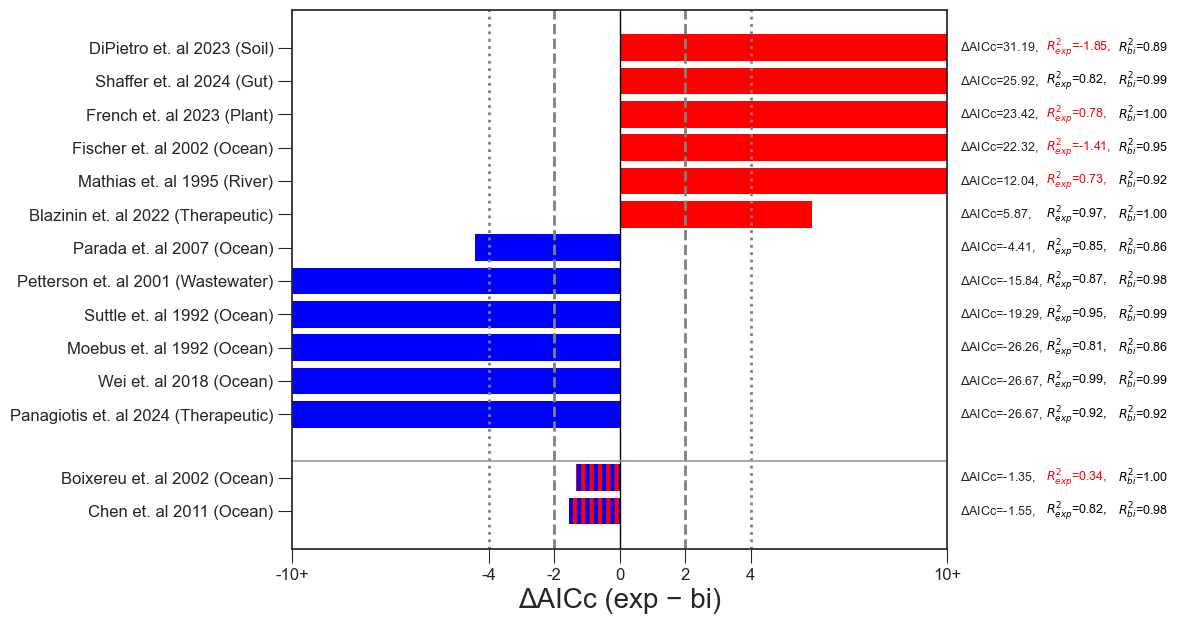

In [22]:

# Data
data = {"Paper": ["Blazinin et. al 2022 (Therapeutic)", "Fischer et. al 2002 (Ocean)", "Tsai et. al 2022 (River)", "Petterson et. al 2001 (Wastewater)", "Parada et. al 2007 (Ocean)", "Mathias et. al 1995 (River)", "DiPietro et. al 2023 (Soil)", "Wei et. al 2018 (Ocean)", "Pleyer et. al 2024 (River)", "Fischer et. al 2004 (Ocean)", "Boixereu et. al 2002 (Ocean)", "Shaffer et. al 2024 (Gut)", "Suttle et. al 1992 (Ocean)", "Chen et. al 2011 (Ocean)", "French et. al 2023 (Plant)", "Panagiotis et. al 2024 (Therapeutic)", "Moebus et. al 1992 (Ocean)"], "DeltaAICc": DeltaAICc,}

# Assemble dataframe
df = pd.DataFrame({"Paper": data["Paper"], "DeltaAICc": np.asarray(DeltaAICc, dtype=float), "R2exp": np.asarray(R2exp, dtype=float), "R2bi": np.asarray(R2bi, dtype=float),})

# Winning-model R²
df["R2"] = np.where(df["DeltaAICc"] > 0, df["R2bi"], df["R2exp"])

# Clip for plotting
clip_val = 10
df["Clipped"] = df["DeltaAICc"].clip(-clip_val, clip_val)

# Categorize
r2_thresh = 0.8
tie_thresh = 2.0

df["tie"] = np.abs(df["DeltaAICc"]) < tie_thresh
df["R2_best"] = df[["R2exp", "R2bi"]].max(axis=1)

df["Category"] = np.where(df["tie"], np.where(df["R2_best"] >= r2_thresh, "Indistinguishable", "Poor fit"), np.where(df["R2"] >= r2_thresh, "Decisive", "Poor fit"))

# Remove poor fits entirely
df = df[df["Category"] != "Poor fit"].copy()

# Moderate wins threshold
moderate_thresh = 4.0
df["ModerateWin"] = (df["Category"] == "Decisive") & (np.abs(df["DeltaAICc"]) < moderate_thresh)

# Colors
blue_strong   = "blue"
orange_strong = "red"
blue_light    = "#9ecae1"
orange_light  = "red"

def facecolor_for_row(row):
    if row["Category"] == "Indistinguishable":
        return "white"
    if row["ModerateWin"]:
        return blue_light if row["DeltaAICc"] < 0 else orange_light
    return blue_strong if row["DeltaAICc"] < 0 else orange_strong

df["FaceColor"] = df.apply(facecolor_for_row, axis=1)

# Order sections
cat_order = {"Decisive": 1, "Indistinguishable": 0}

df = df.sort_values(by=["Category", "DeltaAICc"], key=lambda s: s.map(cat_order) if s.name == "Category" else s).reset_index(drop=True)

# Build y positions
gap = 0.9
ypos = []
y = 0
section_breaks = []
prev = None

for cat in df["Category"]:
    if prev is None:
        prev = cat
    elif cat != prev:
        section_breaks.append(y - 0.5)
        y += gap
        prev = cat
    ypos.append(y)
    y += 1

df["y"] = ypos

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(right=0.78)

bars = ax.barh(df["y"], df["Clipped"], color=df["FaceColor"], edgecolor="none")

# Add alternating blue/orange stripes for indistinguishable
matplotlib.rcParams["hatch.linewidth"] = 3.0

for bar, cat in zip(bars, df["Category"]):
    if cat != "Indistinguishable":
        continue
    ymid = bar.get_y() + bar.get_height() / 2
    w = bar.get_width()
    h = bar.get_height()
    x = bar.get_x()
    ax.barh(ymid, w, height=h, left=x, color="red", edgecolor=blue_strong, hatch="||", linewidth=0, zorder=5)

# Axis labels
ax.set_yticks(df["y"])
ax.set_yticklabels(df["Paper"])

# Reference lines
ax.axvline(0, color="black", linewidth=1)
ax.axvline(-2, color="gray", linestyle="--", linewidth=2)
ax.axvline(2, color="gray", linestyle="--", linewidth=2)
ax.axvline(-4, color="gray", linestyle=":", linewidth=2)
ax.axvline(4, color="gray", linestyle=":", linewidth=2)

# Section dividers
for ydiv in section_breaks:
    ax.axhline(ydiv, color="0.6", linewidth=1.2)

# Right side annotations
for bar, da, r2e, r2b in zip(bars, df["DeltaAICc"], df["R2exp"], df["R2bi"]):
    ytxt = bar.get_y() + bar.get_height() / 2
    exp_color = "red" if r2e < 0.8 else "black"
    bi_color  = "red" if r2b < 0.8 else "black"
    ax.text(1.02, ytxt, f"$\\Delta$AICc={da:.2f}, ", transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=9)
    ax.text(1.15, ytxt, f"$R^2_{{exp}}$={r2e:.2f}, ", transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=9, color=exp_color,)
    ax.text(1.26, ytxt, f"$R^2_{{bi}}$={r2b:.2f}", transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=9, color=bi_color,)

# Labels
ax.set_xlabel("ΔAICc (exp − bi)")
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlim(-clip_val, clip_val)
ax.set_xticks([-10, -4, -2, 0, 2, 4, 10])
ax.set_xticklabels(["-10+", "-4", "-2", "0", "2", "4", "10+"])

plt.savefig("Model_Support_AICc.pdf", bbox_inches="tight")
plt.show()